In [ ]:
# ============================================
# Worksheet - 4: Devnagari Handwritten Digit Classification
# Building Fully Connected Neural Network with Keras
# ============================================

import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tf.keras.__version__}")

TensorFlow version: 2.19.0
Keras version: 3.13.2


In [ ]:
import zipfile
import os
from tqdm import tqdm

def extract_zip_with_progress(zip_path, extract_to='/content'):
    """Extract ZIP file with a progress bar."""
    os.makedirs(extract_to, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        members = zip_ref.infolist()
        total = len(members)

        print(f"📦 Found {total} files | Size: {sum(m.file_size for m in members) / 1e6:.1f} MB")

        for member in tqdm(members, desc="Extracting", unit="file"):
            zip_ref.extract(member, extract_to)

    print(f"✅ Done! Files saved to: {extract_to}")

# Usage
extract_zip_with_progress('/content/drive/MyDrive/Sem6AI/Week4/Copy of Copy of devnagari digit.zip', '/content/output')

📦 Found 20000 files | Size: 12.0 MB


Extracting: 100%|██████████| 20000/20000 [00:02<00:00, 7140.96file/s]

✅ Done! Files saved to: /content/output


In [ ]:
# ============================================
# TASK 1: Data Preparation
# ============================================

# Define dataset paths (UPDATE THESE PATHS TO YOUR DATASET LOCATION)
train_dir = "/content/output/DevanagariHandwrittenDigitDataset/Train"  # Change to your train folder path
test_dir = "/content/output/DevanagariHandwrittenDigitDataset/Test"    # Change to your test folder path

# Define image size
img_height, img_width = 28, 28

def load_images_from_folder(folder):
    """
    Load images from folder structure using PIL.
    Expected structure: folder/class_name/image_files
    """
    images = []
    labels = []

    # Get sorted class names (assuming folders like '0', '1', '2', ... or 'digit_0', etc.)
    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    print(f"Found classes: {class_names}")
    print(f"Class mapping: {class_map}")

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        # Skip if not a directory
        if not os.path.isdir(class_path):
            continue

        for filename in os.listdir(class_path):
            if filename.endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                img_path = os.path.join(class_path, filename)

                try:
                    # Load image using PIL
                    img = Image.open(img_path).convert("L")  # Convert to grayscale
                    img = img.resize((img_width, img_height))  # Resize to 28x28
                    img = np.array(img) / 255.0  # Normalize to [0, 1]
                    images.append(img)
                    labels.append(label)
                except Exception as e:
                    print(f"Error loading {img_path}: {e}")

    return np.array(images), np.array(labels)

# Load training and testing datasets
print("Loading training data...")
x_train, y_train = load_images_from_folder(train_dir)
print(f"Training data loaded: {x_train.shape}, Labels: {y_train.shape}")

print("\nLoading testing data...")
x_test, y_test = load_images_from_folder(test_dir)
print(f"Testing data loaded: {x_test.shape}, Labels: {y_test.shape}")

# Reshape images for Keras input (add channel dimension)
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels (for categorical_crossentropy)
num_classes = len(np.unique(y_train))
y_train_categorical = to_categorical(y_train, num_classes)
y_test_categorical = to_categorical(y_test, num_classes)

print(f"\nAfter preprocessing:")
print(f"Training set shape: {x_train.shape}")
print(f"Training labels shape: {y_train_categorical.shape}")
print(f"Testing set shape: {x_test.shape}")
print(f"Testing labels shape: {y_test_categorical.shape}")
print(f"Number of classes: {num_classes}")

Loading training data...
Found classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
Training data loaded: (17000, 28, 28), Labels: (17000,)

Loading testing data...
Found classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
Testing data loaded: (3000, 28, 28), Labels: (3000,)

After preprocessing:
Training set shape: (17000, 28, 28, 1)
Training labels shape: (17000, 10)
Testing set shape: (3000, 28, 28, 1)
Testing labels shape: (3000, 10)
Number of classes: 10


Checking the Version

In [ ]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


Using Numpy to Calculate :
✓Works for Simple cases
• ✗ Hard to scale for deeper networks

In [ ]:
import numpy as np
# Simple function f(x) = x^2
def f(x):
  return x ** 2
# Manual derivative (f’(x) = 2x)
def gradient(x):
  return 2 * x
# Update rule: x = x - learning_rate * gradient
x = 5.0
learning_rate = 0.1
for _ in range(10): # Manually optimize for 10 steps
  x -= learning_rate * gradient(x)
  print(f"x: {x}, f(x): {f(x)}")

x: 4.0, f(x): 16.0
x: 3.2, f(x): 10.240000000000002
x: 2.56, f(x): 6.5536
x: 2.048, f(x): 4.194304
x: 1.6384, f(x): 2.68435456
x: 1.31072, f(x): 1.7179869184000003
x: 1.0485760000000002, f(x): 1.0995116277760004
x: 0.8388608000000002, f(x): 0.7036874417766403
x: 0.6710886400000001, f(x): 0.45035996273704976
x: 0.5368709120000001, f(x): 0.2882303761517119


Gradient Computation: with KERAS
We do not have to compute gradients manually.
✓Scales to large networks.

In [ ]:
import tensorflow as tf
x = tf.Variable(5.0) # Trainable variable
with tf.GradientTape() as tape:
  y = x ** 2 # y = x^2
grad = tape.gradient(y, x) # Computes dy/dx automatically
print(grad.numpy()) # Output: 10.0

10.0


NUMPY is slow for large Models.
Numpy runs only on CPU and does not support GPU acceleration.

Deep Learning requires millions of matrix operations, which Numpy alone can not optimize efficiently.

In [ ]:
#Matrix Multiplication Speed (Numpy vs. Tensorflow on GPU).
import numpy as np
import tensorflow as tf
import time
# Create large random matrices
size = (1000, 1000)
A = np.random.rand(*size)
B = np.random.rand(*size)
# NumPy Multiplication
start = time.time()
C_numpy = np.dot(A, B)
print("NumPy Time:", time.time() - start)
# TensorFlow Multiplication (for colab uses GPU Runtime if available)
A_tf = tf.constant(A)
B_tf = tf.constant(B)
start = time.time()
C_tf = tf.matmul(A_tf, B_tf)
print("TensorFlow Time:", time.time() - start)

NumPy Time: 0.06653404235839844
TensorFlow Time: 0.12475156784057617


No Pre-built Activation Functions and Layers in NumPy.
In deep learning, we use functions like:
• sigmoid:
• Softmax:
With Numpy we’d have to manually implement every function. In keras it already has built it.

In [ ]:
#Implementation of Activation Function with Keras.
from tensorflow.keras.layers import Dense
layer = Dense(64, activation='sigmoid')

Keras supports Model Training, Numpy Does not:
Once your model is built, training it in Numpy is complex:
• Compute forward pass.
• Compute loss.
• Compute backward pass manually.
• Update weights using gradients.

In [ ]:
import numpy as np

# Example data (just for understanding)
x_train = np.array([[1, 2], [3, 4], [5, 6]])
y_train = np.array([1, 2, 3])

# Initialize weights
weights = np.random.randn(x_train.shape[1])

learning_rate = 0.01

# Training loop
for epoch in range(10):
    # Forward pass
    y_pred = np.dot(x_train, weights)

    # Compute loss
    loss = np.mean((y_pred - y_train) ** 2)

    # Compute gradients
    gradients = 2 * np.dot(x_train.T, (y_pred - y_train)) / len(x_train)

    # Update weights
    weights -= learning_rate * gradients

    print(f"Epoch {epoch}, Loss: {loss}")

Epoch 0, Loss: 24.48841957086154
Epoch 1, Loss: 3.8544469406844186
Epoch 2, Loss: 0.633342920958272
Epoch 3, Loss: 0.1304125127380711
Epoch 4, Loss: 0.05179321142463047
Epoch 5, Loss: 0.039409860810350916
Epoch 6, Loss: 0.037366425319457004
Epoch 7, Loss: 0.03693745401173826
Epoch 8, Loss: 0.03676089038483817
Epoch 9, Loss: 0.03662411414242591




**No prebuilt Layers in numpy **



```



In [ ]:
#layers in Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential([Dense(64, activation='relu', input_shape=(784,)),Dense(10, activation='softmax')])

No prebuilt Optimizers in NumPy:
Deep learning requires optimization algorithms like:
• SGD (Stochastic Gradient Descent) or Mini - Batch Gradient Descent.
• Adam (Adaptive Momentum Estimation){ we will discuss this in upcoming weeks.}

Implementing SDG in numpy
It does works but hard to scale  in complex models.

In [ ]:
learning_rate = 0.01
weights = np.random.randn(3, 3)
for _ in range(100): # Training loop
  gradient = np.random.randn(3, 3) # Fake gradient for illustration
  weights -= learning_rate * gradient

In Keras

In [ ]:
from tensorflow.keras.optimizers import SGD
optimizer = SGD(learning_rate=0.01)

Understanding Fully Connected Layers

1. Dense Class in Keras:



In [ ]:
from tensorflow.keras.layers import Dense
layer = Dense(units=10, activation=None, use_bias=True, kernel_initializer="glorot_uniform")

A Dense Layer with 64 Neurons and sigmoid Activation.

In [ ]:
from tensorflow.keras.layers import Dense
layer = Dense(64, activation="sigmoid") # 64 neurons with sigmoid activation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading and Preprocessing Data with PIL.

Training set: (2544, 28, 28, 1), Labels: (2544, 10)
Testing set: (0, 28, 28, 1), Labels: (0, 10)


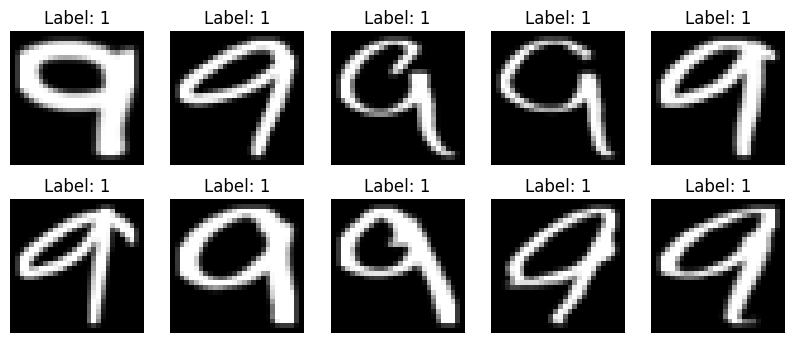

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image  # Import Pillow

# Define dataset paths
train_dir = "/content/drive/MyDrive/Sem6AI/Week4/DevanagariHandwrittenDigitDataset/Train/"
test_dir = "/content/drive/MyDrive/Sem6AI/Week4/DevanagariHandwrittenDigitDataset/Test/"

# Define image size
img_height, img_width = 28, 28

# Function to load images and labels using PIL
def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))  # Sorted class names
    class_map = {name: i for i, name in enumerate(class_names)}  # Map class names to labels

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            # Load image using PIL
            img = Image.open(img_path).convert("L")  # Convert to grayscale
            img = img.resize((img_width, img_height))  # Resize
            img = np.array(img) / 255.0  # Normalize

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")

plt.show()

Compatibility Check for Grayscale Image


In [ ]:
x_train = x_train.reshape(-1, img_height, img_width, 1)
# Use with Cautions.

Compatibility check for RGB Image

In [ ]:
x_train = x_train.reshape(-1, img_height, img_width, 3)
# Use with Cautions.

Loading and Preprocessing MNIST Handwritten Digit Dataset

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Normalize the images to values between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0
# Flatten the 28x28 images into 784-dimensional vectors
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)
# One-hot encode the labels (0-9) for classification
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Building the Model


Sequential API

In [ ]:
# Model parameters
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
model = keras.Sequential(
[
keras.layers.Input(shape=input_shape),
keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
keras.layers.Dense(64, activation="sigmoid"),
keras.layers.Dense(128, activation="sigmoid"),
keras.layers.Dense(256, activation="sigmoid"),
keras.layers.Dense(num_classes, activation="softmax"),
]
)

In [ ]:
#Syntax Model Summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Functional API
# Model parameters
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
def build_functional_model():
# Input layer
  inputs = keras.Input(shape=input_shape)
  # Flatten layer
  x = keras.layers.Flatten()(inputs)
  # Hidden layers
  x = keras.layers.Dense(64, activation="sigmoid")(x)
  x = keras.layers.Dense(128, activation="sigmoid")(x)
  x = keras.layers.Dense(256, activation="sigmoid")(x)
  # Output layer
  outputs = keras.layers.Dense(num_classes, activation="softmax")(x)
  # Create model
  model = keras.Model(inputs=inputs, outputs=outputs)
  return model
# Build the model
functional_model = build_functional_model()
functional_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Compiling and Training the Model

Compiling the Model


In [ ]:
model.compile(
optimizer="sgd", # Stochastic Gradient Descent
loss="categorical_crossentropy", # Loss function for multi-class classification
metrics=["accuracy"] # Track accuracy during training
)

Training the Model(fit function)

In [ ]:
# 2. Reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# 3. Build model (IMPORTANT)
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# 4. Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 5. Train
history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.15
)

Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 34s 81ms/step - accuracy: 0.9337 - loss: 0.2303 - val_accuracy: 0.9790 - val_loss: 0.0839
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 40s 78ms/step - accuracy: 0.9780 - loss: 0.0740 - val_accuracy: 0.9798 - val_loss: 0.0702
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.9861 - loss: 0.0476 - val_accuracy: 0.9853 - val_loss: 0.0565
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - accuracy: 0.9892 - loss: 0.0355 - val_accuracy: 0.9870 - val_loss: 0.0472
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.9920 - loss: 0.0271 - val_accuracy: 0.9856 - val_loss: 0.0499
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 40s 65ms/step - accuracy: 0.9945 - loss: 0.0198 - val_accuracy: 0.9868 - val_loss: 0.0501
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - accuracy: 0.9956 - loss: 0.0153 - val_accuracy: 0.9870 - val_loss: 0.0501
Epoch 8/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.9966 - loss: 0.0115 - 

Visualizating Model's Training Progress

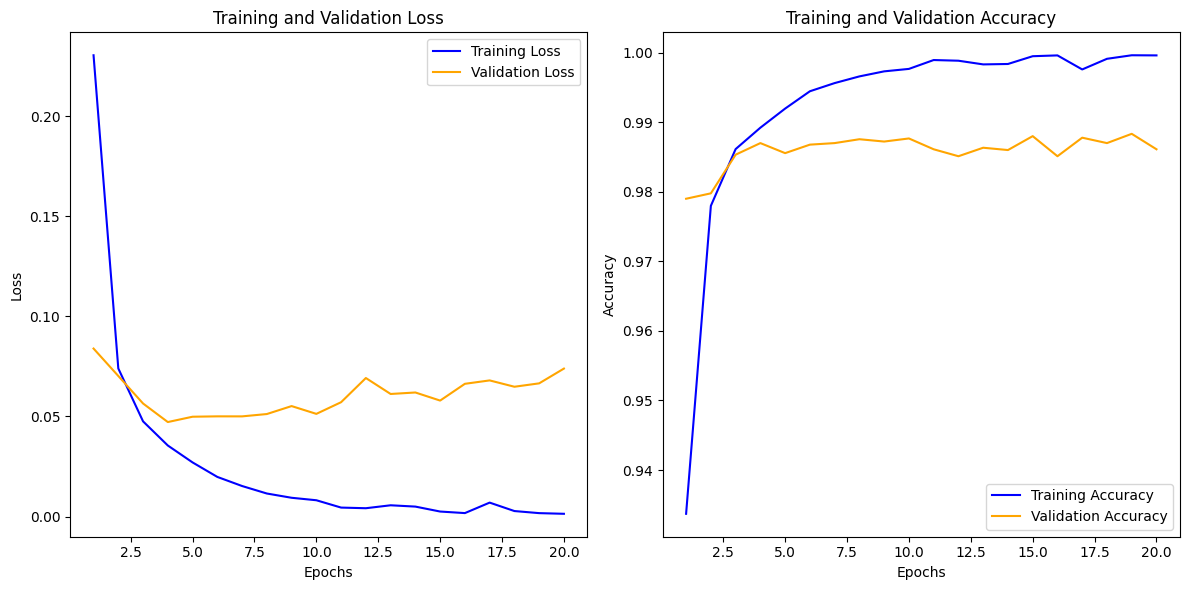

In [ ]:
import matplotlib.pyplot as plt
# Assuming ’history’ is the object returned by model.fit()
# Extracting training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']
# Extracting training and validation accuracy (if metrics were specified)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
# Plotting training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss', color='blue')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

Evaluating the Model

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

313/313 - 2s - 8ms/step - accuracy: 0.9845 - loss: 0.0667
Test accuracy: 0.9845


Making Prediction with Keras

In [ ]:
# Select a few samples from test data
x_sample = x_test[:5]

# Make predictions
predictions = model.predict(x_sample, batch_size=128)

# Print raw prediction probabilities
print(predictions)

# Convert probabilities to class labels
predicted_labels = predictions.argmax(axis=1)
print("Predicted labels:", predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
[[3.9895457e-17 4.1662715e-14 1.5902341e-10 7.3276220e-12 1.0136670e-19
  1.2444897e-18 1.7789027e-22 1.0000000e+00 1.3666874e-14 9.4903286e-14]
 [4.7120215e-16 4.8839983e-15 1.0000000e+00 8.1202594e-19 1.7279962e-23
  2.2772869e-26 1.9543364e-13 3.5491463e-25 4.6824866e-18 6.1759952e-17]
 [1.5481194e-07 9.9998415e-01 1.7441843e-06 7.1135835e-09 3.5150056e-06
  5.6813009e-11 2.4878207e-07 2.0199500e-06 8.1017906e-06 5.8082722e-10]
 [1.0000000e+00 4.2952101e-15 1.6376641e-11 1.0155036e-15 1.2659866e-14
  7.3209301e-16 1.2568233e-09 2.4396295e-14 6.0675278e-16 5.2678787e-13]
 [1.9185413e-12 6.1052774e-13 1.3402241e-08 1.6024287e-13 1.0000000e+00
  1.6023249e-13 7.0669387e-11 1.7694625e-13 1.5100984e-10 2.6794631e-08]]
Predicted labels: [7 2 1 0 4]


Model.predict()

In [ ]:
# Predict on test data
predictions = model.predict(x_test)
# Convert predictions from probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)
# Check the first prediction
print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {np.argmax(y_test[0])}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Predicted label for first image: 7
True label for first image: 7


Saving the Model

In [ ]:
model.save('mnist_fully_connected_model.h5')

Loading the Model

In [ ]:
loaded_model = tf.keras.models.load_model('mnist_fully_connected_model.h5')

WORKSHOP TASK STARTS HERE

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from PIL import Image
import matplotlib.pyplot as plt

# Update these to match your folder names exactly
# Usually, it's /content/DevanagariHandwrittenDigitDataset/Train
base_path = "/content/drive/MyDrive/Sem6AI/Week4/DevanagariHandwrittenDigitDataset"
train_dir = os.path.join(base_path, "Train")
test_dir = os.path.join(base_path, "Test")

img_height, img_width = 28, 28

In [43]:
import os
import numpy as np
from tensorflow.keras.utils import to_categorical
from PIL import Image

# 1. Update this path to the EXACT folder name you copied
# It should look like this: /content/drive/MyDrive/Sem6AI/Week4/DevanagariHandwrittenDigitDataset
base_path = "/content/output/DevanagariHandwrittenDigitDataset"

train_dir = os.path.join(base_path, "Train")
test_dir = os.path.join(base_path, "Test")

def load_from_directory(directory):
    images, labels = [], []
    # This looks for digit_0, digit_1... folders
    categories = sorted([d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))])

    for idx, cat in enumerate(categories):
        cat_path = os.path.join(directory, cat)
        for img_name in os.listdir(cat_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                img = Image.open(os.path.join(cat_path, img_name)).convert("L").resize((28, 28))
                images.append(np.array(img) / 255.0)
                labels.append(idx)
    return np.array(images), np.array(labels)

print("Loading Train and Test sets...")
x_train, y_train = load_from_directory(train_dir)
x_test, y_test = load_from_directory(test_dir)

# Reshape for the model and One-Hot Encode
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f" Loaded {len(x_train)} training images and {len(x_test)} testing images.")

Loading Train and Test sets...
✅ Loaded 17000 training images and 3000 testing images.


In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

# Initializing the Sequential model
model = Sequential([
    # Task 2: Build the architecture
    # Flatten converts 2D (28,28) images into a 1D vector of 784 pixels
    Flatten(input_shape=(28, 28, 1)),

    # Hidden Layer 1: 512 neurons with ReLU activation
    Dense(512, activation='relu'),

    # Hidden Layer 2: 256 neurons with ReLU activation
    Dense(256, activation='relu'),

    # Output Layer: 10 neurons (one for each digit 0-9)
    # Softmax provides probability for each class
    Dense(10, activation='softmax')
])

# Display the summary of the architecture
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# Task 3: Compile the Model
model.compile(
    optimizer='adam',                # Efficient optimization algorithm
    loss='categorical_crossentropy', # Used because we have one-hot encoded labels
    metrics=['accuracy']             # We want to track accuracy
)

In [46]:
# Task 4: Train the Model
history = model.fit(
    x_train, y_train_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.2, # Monitor performance on a 20% slice of training data
    verbose=1
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9082 - loss: 0.2897 - val_accuracy: 0.0000e+00 - val_loss: 14.9481
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9765 - loss: 0.0824 - val_accuracy: 0.0000e+00 - val_loss: 14.4060
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9864 - loss: 0.0475 - val_accuracy: 0.0000e+00 - val_loss: 13.9470
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9925 - loss: 0.0271 - val_accuracy: 0.0000e+00 - val_loss: 15.7509
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9964 - loss: 0.0146 - val_accuracy: 0.0000e+00 - val_loss: 16.4873
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9979 - loss: 0.0087 - val_accuracy: 0.0000e+00 - val_loss: 17.7594
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9984 - loss: 0.0068 - val_accuracy: 0.0000e+00 - val_loss: 17.5905
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accurac

In [47]:
# Task 5: Evaluate the Model
test_loss, test_acc = model.evaluate(x_test, y_test_cat)
print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

# Task 6: Save the Model
# This creates a file named 'devnagari_model.h5' in your Colab files
model.save("devnagari_model.h5")
print("Model successfully saved as devnagari_model.h5")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7913 - loss: 4.0752



Final Test Accuracy: 79.13%
Model successfully saved as devnagari_model.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step


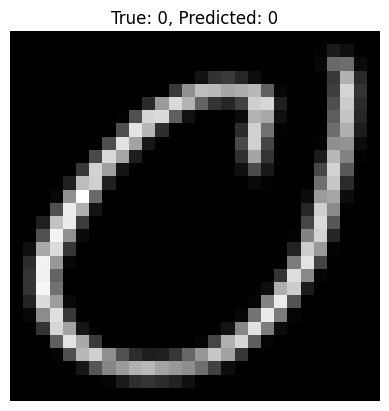

The model predicts this digit is: 0


In [48]:
import numpy as np

# Pick a random image from the test set
index = 0
img = x_test[index]
true_label = np.argmax(y_test_cat[index])

# Task 7: Make a prediction
prediction = model.predict(img.reshape(1, 28, 28, 1))
predicted_label = np.argmax(prediction)

# Visualize the result
plt.imshow(img.reshape(28, 28), cmap='gray')
plt.title(f"True: {true_label}, Predicted: {predicted_label}")
plt.axis('off')
plt.show()

print(f"The model predicts this digit is: {predicted_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


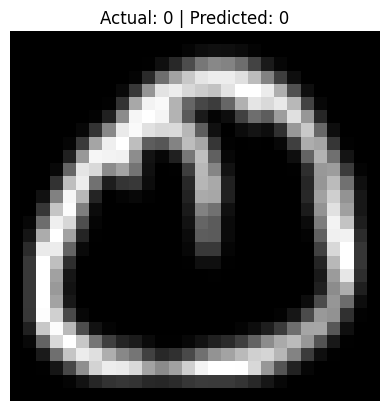

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Grab one image from your test set
test_img = x_test[5]
actual_label = np.argmax(y_test_cat[5])

# Get the model's prediction
pred_probs = model.predict(test_img.reshape(1, 28, 28, 1))
predicted_label = np.argmax(pred_probs)

# Show it
plt.imshow(test_img.reshape(28, 28), cmap='gray')
plt.title(f"Actual: {actual_label} | Predicted: {predicted_label}")
plt.axis('off')
plt.show()

In [50]:
# Test the model on the first image of the test set
test_image = x_test[0].reshape(1, 28, 28, 1)
pred = model.predict(test_image)
digit = np.argmax(pred)

print(f"The model identifies this Devnagari digit as: {digit}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
The model identifies this Devnagari digit as: 0
